<a href="https://colab.research.google.com/github/Megh-05/Data-Science/blob/main/Exp_No_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

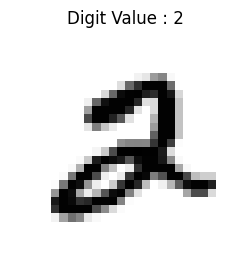

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 416,910 (1.59 MB)

 Trainable params: 416,110 (1.59 MB)

 Non-trainable params: 800 (3.12 KB)

Epoch 1/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9077 - loss: 0.3032 - val_accuracy: 0.9650 - val_loss: 0.1203
Epoch 2/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9508 - loss: 0.1603 - val_accuracy: 0.9712 - val_loss: 0.0939
Epoch 3/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9610 - loss: 0.1271 - val_accuracy: 0.9746 - val_loss: 0.0895
Epoch 4/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9669 - loss: 0.1080 - val_accuracy: 0.9766 - val_loss: 0.0781
Epoch 5/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9682 - loss: 0.1008 - val_accuracy: 0.9762 - val_loss: 0.0792
Epoch 6/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9718 - loss: 0.0879 - val_accuracy: 0.9773 - val_loss: 0.0788
Epoch 7/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9753 - loss: 0.0801 - val_accuracy: 0.9781 - val_loss: 0.0749
Epoch 8/8
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9767 - loss: 0.0747 - val_accuracy: 0.9770 - v

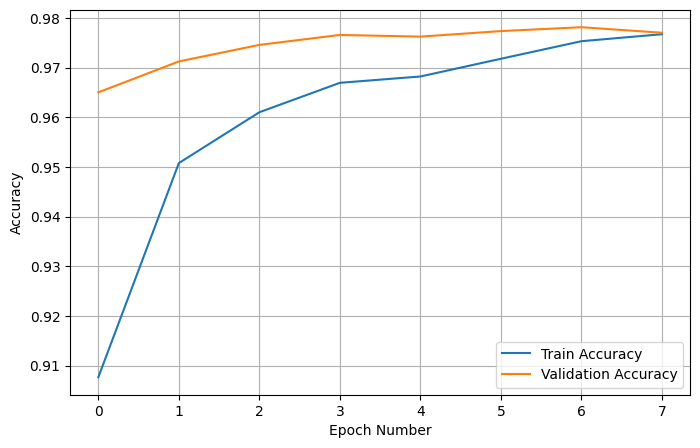

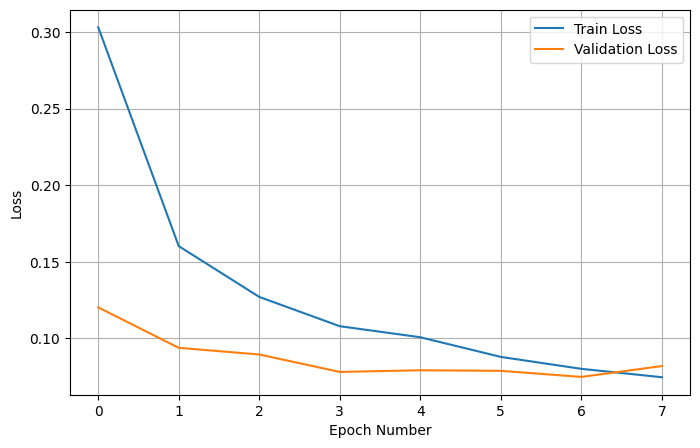

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

Predicted Digit : 7


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

# Load Handwritten Digit Dataset

(train_data, train_target), (test_data, test_target) = mnist.load_data()

# Show Example Image

sample_number = 5

plt.figure(figsize=(3,3))

plt.imshow(
    train_data[sample_number],
    cmap='binary'
)

plt.title(f"Digit Value : {train_target[sample_number]}")

plt.axis("off")

plt.show()

# Normalize Pixel Values

train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

# Convert 2D Image into 1D Vector

train_data = train_data.reshape(-1, 784)
test_data = test_data.reshape(-1, 784)

# Convert Labels into Categorical Form

train_target = to_categorical(train_target, 10)
test_target = to_categorical(test_target, 10)

# Create ANN Model

digit_classifier = Sequential()

# First Dense Layer

digit_classifier.add(
    Dense(
        400,
        activation='relu',
        input_shape=(784,)
    )
)

digit_classifier.add(BatchNormalization())

digit_classifier.add(Dropout(0.3))

# Second Dense Layer

digit_classifier.add(
    Dense(
        200,
        activation='relu'
    )
)

digit_classifier.add(Dropout(0.25))

# Third Dense Layer

digit_classifier.add(
    Dense(
        100,
        activation='relu'
    )
)

# Output Layer

digit_classifier.add(
    Dense(
        10,
        activation='softmax'
    )
)

# Display Model Summary

digit_classifier.summary()

# Compile Neural Network

digit_classifier.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model

model_history = digit_classifier.fit(
    train_data,
    train_target,
    epochs=8,
    batch_size=64,
    validation_split=0.15
)

# Evaluate Model

final_loss, final_accuracy = digit_classifier.evaluate(
    test_data,
    test_target
)

print("\nTesting Loss :", final_loss)
print("Testing Accuracy :", final_accuracy)

# Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(
    model_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    model_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)

plt.show()

# Loss Graph

plt.figure(figsize=(8,5))

plt.plot(
    model_history.history['loss'],
    label='Train Loss'
)

plt.plot(
    model_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.show()

# Predict One Digit

test_prediction = digit_classifier.predict(test_data[0:1])

predicted_output = np.argmax(test_prediction)

print("\nPredicted Digit :", predicted_output)